# YOLO11 Object Detection & Tracking Pipeline

**Dataset**: BDD100K subset — 700 images (490 train / 140 val / 70 test)  
**Labels**: 700 total labels (490 train / 140 val / 70 test)  
**Model**: YOLO11s (medium) — optimized for CPU / low-memory machines

## Cell 1 – Verify 700 Subset Exists
The 700 dataset is already created at `Object/700/`.  
This cell just confirms the file counts — no copying needed.

In [1]:
import os

# Main project folder path
# Change this path only if you move your project folder to another location
base_dir = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'

# Dataset folder path
dataset_dir = os.path.join(base_dir, '700')

print("Project Folder:", base_dir)
print("Dataset Folder:", dataset_dir)
print()

# Checking images and labels for train, validation, and test folders
for split in ['train', 'val', 'test']:
    image_folder = os.path.join(dataset_dir, 'images', split)
    label_folder = os.path.join(dataset_dir, 'labels', split)

    # Count image files
    if os.path.exists(image_folder):
        image_count = len([
            file for file in os.listdir(image_folder)
            if file.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
    else:
        image_count = 0

    # Count label files
    if os.path.exists(label_folder):
        label_count = len([
            file for file in os.listdir(label_folder)
            if file.endswith('.txt')
        ])
    else:
        label_count = 0

    # Show folder status
    if image_count > 0:
        status = "✅ Found"
    else:
        status = "❌ Not Found"

    print(f"{status} {split} data -> Images: {image_count}, Labels: {label_count}")

# Check whether the YOLO data YAML file exists or not
yaml_file = os.path.join(base_dir, 'data_700.yaml')

print()
if os.path.exists(yaml_file):
    print("✅ data_700.yaml file is available.")
else:
    print("❌ data_700.yaml file is missing. Please run the dataset setup cell first.")

Project Folder: C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object
Dataset Folder: C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\700

✅ Found train data -> Images: 490, Labels: 490
✅ Found val data -> Images: 140, Labels: 140
✅ Found test data -> Images: 70, Labels: 70

✅ data_700.yaml file is available.


## Cell 2 – Write / Refresh data_700.yaml

In [2]:
import os

BASE_DIR  = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'
yaml_path = os.path.join(BASE_DIR, 'data_700.yaml')
dataset   = BASE_DIR.replace('\\', '/') + '/700'

yaml_content = (
    f'path: {dataset}\n'
    '\n'
    'train: images/train\n'
    'val:   images/val\n'
    'test:  images/test\n'
    '\n'
    'nc: 6\n'
    'names: ["car", "bus", "truck", "motorcycle", "bicycle", "person"]\n'
)

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print('✅  data_700.yaml written to:', yaml_path)
print()
print(yaml_content)

✅  data_700.yaml written to: C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\data_700.yaml

path: C:/Users/Shivani Agarwal/Downloads/Garv_minor2/Object/700

train: images/train
val:   images/val
test:  images/test

nc: 6
names: ["car", "bus", "truck", "motorcycle", "bicycle", "person"]



## Cell 3 – Custom Dataset Class (for reference)

In [3]:
import os
import cv2
from torch.utils.data import Dataset

class YOLODataset(Dataset):
    """Lightweight dataset loader for YOLO-format labels."""

    def __init__(self, img_dir, label_dir, img_size=416):
        self.img_dir   = img_dir
        self.label_dir = label_dir
        self.img_size  = img_size
        self.images    = [
            f for f in os.listdir(img_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name   = self.images[idx]
        img_path   = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(
            self.label_dir,
            os.path.splitext(img_name)[0] + '.txt'
        )

        img = cv2.imread(img_path)
        if img is None:
            raise FileNotFoundError(f'Cannot read image: {img_path}')
        img = cv2.resize(img, (self.img_size, self.img_size))

        boxes = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, x, y, w, h = map(float, parts)
                        boxes.append([cls, x, y, w, h])

        return img, boxes


# Quick sanity check
BASE_DIR = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'
ds = YOLODataset(
    img_dir   = os.path.join(BASE_DIR, '700', 'images', 'train'),
    label_dir = os.path.join(BASE_DIR, '700', 'labels', 'train')
)
print(f'YOLODataset loaded: {len(ds)} train images')
img, boxes = ds[0]
print(f'Sample image shape : {img.shape}   boxes: {len(boxes)}')

YOLODataset loaded: 490 train images
Sample image shape : (416, 416, 3)   boxes: 7


## Cell 4 – Train YOLO11n on the 700 Subset
Memory-safe settings for CPU / low-RAM machines:

| Setting | Value | Reason |
|---------|-------|--------|
| `imgsz` | 416 | Smaller tensors → less RAM |
| `batch` | 4 | Half the peak memory of batch=8 |
| `workers` | 0 | Avoids Windows multiprocessing issues in Jupyter |
| `cache` | False | Don't load all images into RAM |

In [4]:
import os
import time
from ultralytics import YOLO

BASE_DIR  = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'
data_yaml = os.path.join(BASE_DIR, 'data_700.yaml')

if not os.path.exists(data_yaml):
    raise FileNotFoundError(f'data_700.yaml not found: {data_yaml}\nPlease run Cell 2 first.')

# Remove stale label caches (built for the 10k set) so YOLO rebuilds for 2k
cache_dir = os.path.join(BASE_DIR, '700', 'labels')
for cache_file in ['train.cache', 'val.cache', 'test.cache']:
    cp = os.path.join(cache_dir, cache_file)
    if os.path.exists(cp):
        os.remove(cp)
        print(f'Removed stale cache: {cache_file}')

model = YOLO('yolo11s.pt')

print('\n🚀  Starting training on 700 subset ...\n')
t0 = time.time()

model.train(
    data     = data_yaml,
    epochs   = 10,
    imgsz    = 640,
    batch    = 4,
    workers  = 0,
    cache    = False,
    device   = 'cpu',
    project  = os.path.join(BASE_DIR, 'checkpoints'),
    name     = 'yolo_700_experiment',
    exist_ok = True
)

print(f'\n✅  Training done in {(time.time()-t0)/60:.1f} min.')

Removed stale cache: train.cache
Removed stale cache: val.cache

🚀  Starting training on 700 subset ...

New https://pypi.org/project/ultralytics/8.4.45 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.7  Python-3.13.5 torch-2.9.1+cpu CPU (Intel Core i5-1035G1 1.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\data_700.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_

## Cell 5 – Validate & Print Metrics

In [ ]:
import os
import time
from ultralytics import YOLO

BASE_DIR  = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'
data_yaml = os.path.join(BASE_DIR, 'data_700.yaml')

# Use best.pt from training; fall back to pretrained if training hasn't run
weights = os.path.join(BASE_DIR, 'checkpoints', 'yolo_700_experiment', 'weights', 'best.pt')

if not os.path.exists(weights):
    weights = 'yolo11s.pt'
    print(f'⚠️  Trained weights not found — using pretrained: {weights}')
else:
    print(f'✅  Using trained weights: {weights}')

model = YOLO(weights)

t0 = time.time()

metrics = model.val(
    data=data_yaml,
    imgsz=640,
    batch=4,
    workers=0,
    device='cpu'
)

elapsed = time.time() - t0

# Detection metrics
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

# Accuracy-like value for object detection
accuracy = map50 * 100

print('\n── Evaluation Metrics ──────────────────')
print(f'  Precision        : {precision:.4f}')
print(f'  Recall           : {recall:.4f}')
print(f'  mAP@0.5          : {map50:.4f}')
print(f'  mAP@0.5:0.95     : {map5095:.4f}')
print(f'  Accuracy         : {accuracy:.2f}%')

inf_ms = metrics.speed.get('inference', 0)

print('\n── Speed ───────────────────────────────')
print(f'  Inference / image : {inf_ms:.2f} ms')

if inf_ms > 0:
    print(f'  Approx FPS        : {1000 / inf_ms:.1f}')

print(f'  Total val time    : {elapsed:.1f} s')
print('────────────────────────────────────────')

✅  Using trained weights: C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\checkpoints\yolo_700_experiment\weights\best.pt
Ultralytics 8.4.7  Python-3.13.5 torch-2.9.1+cpu CPU (Intel Core i5-1035G1 1.00GHz)
YOLO11s summary (fused): 101 layers, 9,415,122 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 347.1187.7 MB/s, size: 133.0 KB)
val: Scanning C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\700\labels\val.cache... 140 images, 8 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 140/140 24.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 35/35 1.5it/s 23.7s0.7ss
                   all        140       1072      0.787      0.734      0.823      0.697
                   car        128        902      0.937      0.742       0.89      0.716
                   bus         14         18      0.674      0.833      0.773      0.688
                 truck         35         52      0.

## Cell 6 – Plot Training Results

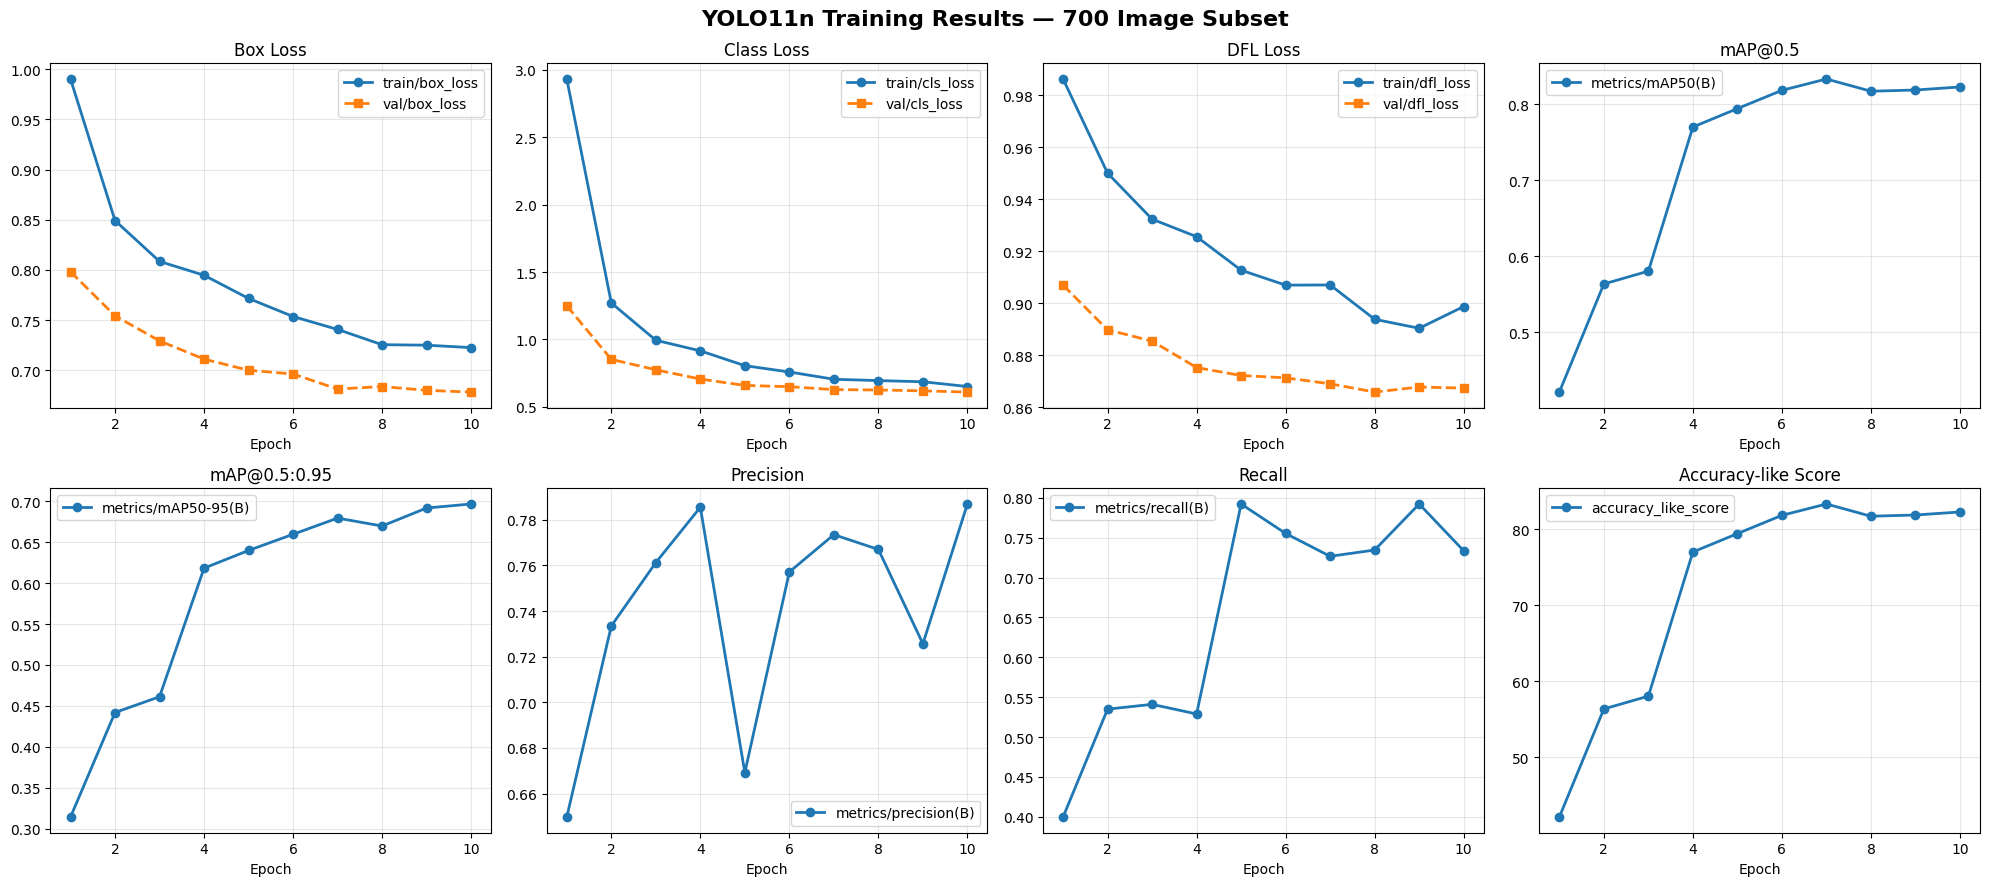

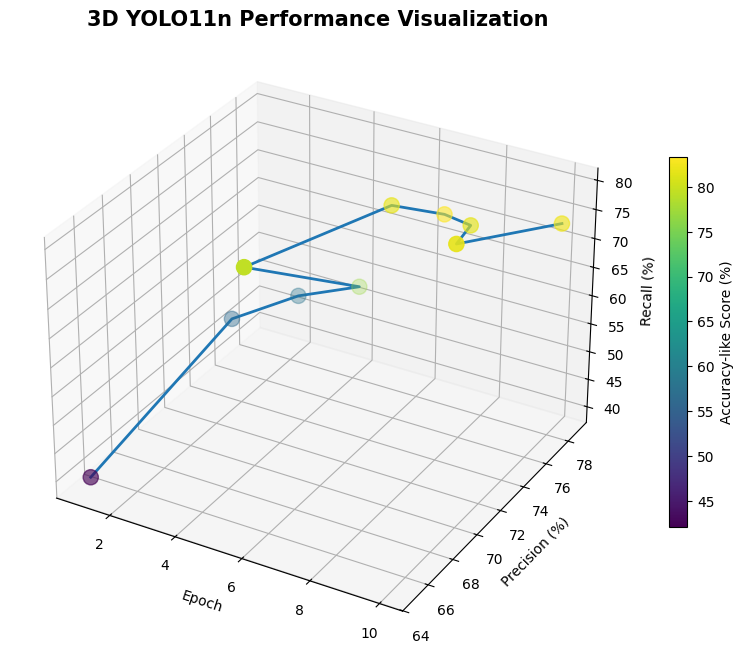

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# For Jupyter Notebook
%matplotlib inline

BASE_DIR = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'
results_csv = os.path.join(BASE_DIR, 'checkpoints', 'yolo_700_experiment', 'results.csv')

if not os.path.exists(results_csv):
    print('results.csv not found — please run training first.')

else:
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    # Accuracy-like score using mAP@0.5
    if 'metrics/mAP50(B)' in df.columns:
        df['accuracy_like_score'] = df['metrics/mAP50(B)'] * 100
    else:
        df['accuracy_like_score'] = 0

    # ---------------- Normal 2D Training Graphs ----------------
    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle(
        'YOLO11n Training Results — 700 Image Subset',
        fontsize=16,
        fontweight='bold'
    )

    plots = [
        ('train/box_loss',       'val/box_loss',        'Box Loss',             axes[0, 0]),
        ('train/cls_loss',       'val/cls_loss',        'Class Loss',           axes[0, 1]),
        ('train/dfl_loss',       'val/dfl_loss',        'DFL Loss',             axes[0, 2]),
        ('metrics/mAP50(B)',     None,                  'mAP@0.5',              axes[0, 3]),

        ('metrics/mAP50-95(B)',  None,                  'mAP@0.5:0.95',         axes[1, 0]),
        ('metrics/precision(B)', None,                  'Precision',            axes[1, 1]),
        ('metrics/recall(B)',    None,                  'Recall',               axes[1, 2]),
        ('accuracy_like_score',  None,                  'Accuracy-like Score',  axes[1, 3]),
    ]

    for train_col, val_col, title, ax in plots:
        if train_col in df.columns:
            ax.plot(
                df['epoch'],
                df[train_col],
                label=train_col,
                marker='o',
                linewidth=2
            )

        if val_col and val_col in df.columns:
            ax.plot(
                df['epoch'],
                df[val_col],
                label=val_col,
                marker='s',
                linewidth=2,
                linestyle='--'
            )

        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

    # ---------------- 3D Performance Graph ----------------
    required_cols = [
        'epoch',
        'metrics/precision(B)',
        'metrics/recall(B)',
        'accuracy_like_score'
    ]

    if all(col in df.columns for col in required_cols):
        fig = plt.figure(figsize=(11, 8))
        ax = fig.add_subplot(111, projection='3d')

        x = df['epoch']
        y = df['metrics/precision(B)'] * 100
        z = df['metrics/recall(B)'] * 100
        c = df['accuracy_like_score']

        graph = ax.scatter(
            x,
            y,
            z,
            c=c,
            s=120,
            cmap='viridis',
            depthshade=True
        )

        ax.plot(x, y, z, linewidth=2)

        ax.set_title(
            '3D YOLO11n Performance Visualization',
            fontsize=15,
            fontweight='bold'
        )

        ax.set_xlabel('Epoch')
        ax.set_ylabel('Precision (%)')
        ax.set_zlabel('Recall (%)')

        color_bar = plt.colorbar(graph, ax=ax, shrink=0.6)
        color_bar.set_label('Accuracy-like Score (%)')

        plt.show()

    else:
        print('Required columns for 3D graph are missing.')

In [ ]:
import os
import cv2
import time
import numpy as np
from ultralytics import YOLO

BASE_DIR = r'C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object'

# Use trained weights if available, else pretrained
weights = os.path.join(BASE_DIR, 'checkpoints', 'yolo_700_experiment', 'weights', 'best.pt')
if not os.path.exists(weights):
    weights = 'yolo11n.pt'
    print(f'Using pretrained weights: {weights}')
else:
    print(f'Using: {weights}')

model = YOLO(weights)
VIDEO = os.path.join(BASE_DIR, '6.mp4')
cap = cv2.VideoCapture(VIDEO)

if not cap.isOpened():
    raise FileNotFoundError(f'Cannot open video: {VIDEO}')

frame_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps_vid = cap.get(cv2.CAP_PROP_FPS)

if fps_vid == 0 or fps_vid is None:
    fps_vid = 25

out_path = os.path.join(BASE_DIR, 'tracking_output.mp4')

writer = cv2.VideoWriter(
    out_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps_vid,
    (frame_w, frame_h)
)

# Counting lines
line_y_red = int(frame_h * 0.35)
line_y_blue = int(frame_h * 0.50)
MARGIN = 8

prev_positions = {}
speeds = {}
count_down = set()
count_up = set()
counted_down = set()
counted_up = set()

total_down = 0
total_up = 0
frame_count = 0
t0 = time.time()

print('Processing video and saving output...')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    results = model.track(frame, persist=True, tracker='bytetrack.yaml', verbose=False)

    if results and results[0].boxes is not None and results[0].boxes.id is not None:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        ids = results[0].boxes.id.cpu().numpy().astype(int)

        for box, tid in zip(boxes, ids):
            x1, y1, x2, y2 = map(int, box)
            cx = (x1 + x2) // 2
            cy = (y1 + y2) // 2

            # Speed in pixels/frame
            if tid in prev_positions:
                pcx, pcy = prev_positions[tid]
                speeds[tid] = np.hypot(cx - pcx, cy - pcy)
            else:
                speeds[tid] = 0.0

            prev_positions[tid] = (cx, cy)

            # Downward crossing: red -> blue
            if line_y_red - MARGIN <= cy <= line_y_red + MARGIN:
                count_down.add(tid)

            if line_y_blue - MARGIN <= cy <= line_y_blue + MARGIN:
                if tid in count_down and tid not in counted_down:
                    total_down += 1
                    counted_down.add(tid)
                    count_down.discard(tid)

            # Upward crossing: blue -> red
            if line_y_blue - MARGIN <= cy <= line_y_blue + MARGIN:
                count_up.add(tid)

            if line_y_red - MARGIN <= cy <= line_y_red + MARGIN:
                if tid in count_up and tid not in counted_up:
                    total_up += 1
                    counted_up.add(tid)
                    count_up.discard(tid)

            # Draw bounding box and center point
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.circle(frame, (cx, cy), 4, (0, 0, 255), -1)

            cv2.putText(
                frame,
                f'ID:{tid} Spd:{speeds[tid]:.1f}',
                (x1, max(y1 - 8, 10)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                1
            )

    # Draw counting lines
    cv2.line(frame, (0, line_y_red), (frame_w, line_y_red), (0, 0, 255), 2)
    cv2.line(frame, (0, line_y_blue), (frame_w, line_y_blue), (255, 0, 0), 2)

    # Overlay stats
    fps_now = frame_count / max(time.time() - t0, 1e-6)
    cv2.putText(frame, f'Down: {total_down}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f'Up: {total_up}', (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    cv2.putText(frame, f'FPS: {fps_now:.1f}', (10, 90), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    # Save frame only
    writer.write(frame)

cap.release()
writer.release()
# cv2.destroyAllWindows()

print('\nDone!')
print(f'Frames processed : {frame_count}')
print(f'Vehicles Down    : {total_down}')
print(f'Vehicles Up      : {total_up}')
print(f'Output saved to  : {out_path}')

Using: C:\Users\Shivani Agarwal\Downloads\Garv_minor2\Object\checkpoints\yolo_700_experiment\weights\best.pt
Processing video and saving output...
